In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import getpass
from sqlalchemy import create_engine

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Database connection
user = "ryan"
password = getpass.getpass("Enter database password: ")
dbname = "home_automation"
host = "ryan-analysis"

engine = create_engine(f"postgresql://{user}:{password}@{host}/{dbname}")
print(f"Connected to database: {dbname} on {host}")


Connected to database: home_automation on ryan-analysis


Retrieved 1 run(s) with 15 reading(s)


,run_id,time,nom_vol,actual_vol,liquid,n_readings,period,vol_per_period,direction,complete,notes
0,126,2025-11-28 21:24:13.381550+00:00,0,None,water,15,5.0,1.0,reverse,False,aluminum in at 5 and off at 10


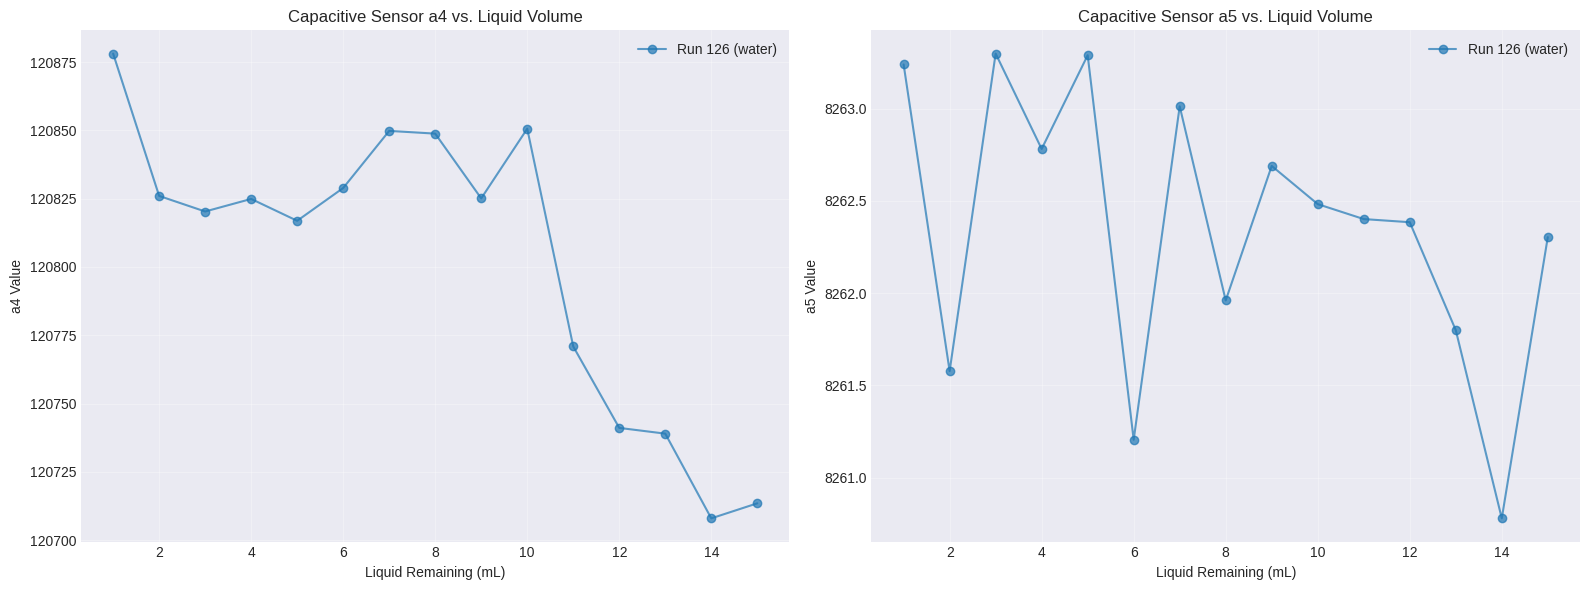

In [45]:
# Specify which run(s) to retrieve
# run_ids = [13, 14, 15, 16, 17, 18]  # 100 ml back and forth
# run_ids = [19, 21, 23, 25, 27]  # filling, 25 is sugar water
# run_ids = [22, 24, 26, 28]  # emptying, 26 is sugar water movements between 47.8k and 50.5k roughly 5 units per ml
# run_ids = [29] # experimenting with moving things, all readings with 40 units, nothing obvious
# run_ids = [30] # moving rasppi towards and away from pump, nothing obvious all readings within about 50 units
# run_ids = [31] # moving my hand towards and away from pump, nothing obvious all readings within about 35 units
# run_ids = [32] # moving my hand towards and away from bottle, big change around 500 units
# run_ids = [33] # grabbing and releasing rca cable near pump, no change all readings within about 40 units
# run_ids = [34] # moving empty tube in bottle at 5 and 10, nothing obiovus all readings within about 35 units
# run_ids = [35] # moving pump towards and away from the reader, moderate change (100-300 units) 
# run_ids = [36, 39] # moving laptop towards and away from the reader, no real change
# run_ids = [37, 38] # moving grounded iec cable towards and away from the reader, moderate chnage (60 units) when moving towards the reader 
# run_ids = [40] # moving UNgrounded iec cable towards and away from the reader, moderate chnage (100 units) when moving towards the reader 
# run_ids = [41] # moving copper pipe towards and away from the reader, big chnage (200 units) when moving towards the reader 
# run_ids = [42] # moving 40 ml water beaker towards and away from the reader, moderate chnage (40 units) when moving towards the reader 
# run_ids = [43, 44] # moving 40 ml water beaker towards and away from the gnd bar, no change
# run_ids = [45, 46] # moving big chunk of steel towards and away from the back 1cm away, big change (100 units) when moving towards the reader 
# run_ids = [47] # moving big sheet of aluminum towards and away from the back 1cm away, big change (150 units) when moving towards the reader 
# run_ids = [48] # moving big sheet of aluminum towards and away from the right side 1cm away, big change (150 units) when moving towards the reader




# run_ids = [49, 51, 53, 55, 57, 59, 61] # filling, 59 is 2ml per trial. before that is 1ml per trial, 61 i moved the metal away from the sensor
# run_ids = [50, 52, 54, 56, 58, 60, 62] # emptying

# fixed calibration...turned out to be innacurate 50mL beaker!
# also turns out that reverse (into the bottle) is about 2.8% slower than forward (out of the bottle)

# run_ids = [70, 72] # emptying
# run_ids = [71, 73] # filling

# run_ids = [75, 77, 79] # first filling runs with new electrode arrangment (2x gnd on either side of 1x sensor. also moved sensor wire to top instead of bottom)

# run_ids = [76, 78, 80] # first emptying runs with new electrode arrangment

# run_ids = [82] # put big chunk of steel behind. worse than before, ~300 increased units
# run_ids = [83, 84] # put big sheet of aluminum beside. nothing at all!


# run_ids = [91, 92, 93, 94, 95, 96, 97, 98, 99, 100] # overnight triangle shaped electrode to try and make the curve more linear
# run_ids = [91, 93, 95, 97, 99] # (fills) overnight triangle shaped electrode to try and make the curve more linear
# run_ids = [92, 94, 96, 98, 100] # (empties) overnight triangle shaped electrode to try and make the curve more linear

# run_ids = [104, 105, 106, 107] # new electrodes with giant ground plane


# run_ids = [ 108 ] # hand in and out, nothing obvious
# run_ids = [ 109 ] # steel in and out, nothing obvious
# run_ids = [ 110 ] # aluminum in and out, maybe 10 units?


# run_ids = [111] # new holder and new electrodes. giant gnd plane, both boards double sided. HORRIBLE! stopped early. vals around 418k

# run_ids = [112, 113] # grabbing cable at 5, releasing at 10. crazy high vals around 420k. seems to be impact of touching cable

# run_ids = [114] # no cable control. vals stable around 11615 +/- 2

# run_ids = [116] # attached cable to juicer not to reader. grabbed cable at 5 released at 10. cals go up from 410.5k to 412.5k

# run_ids = [117] # wired up with the cable coiled up. weirdly climbing entire time from 397k to 399k

# run_ids = [118] # testing again with unshield TRS (390.6k to 391k)

# run_ids = [119] # testing with shielded TRRS (119.2 to 119.4k)

# run_ids = [120] # first filling test with new cable and new holder (119.3 to 121.4k)

# run_ids = [121] # first emptying test with new cable and new holder (119.3 to 121.4k)

run_ids = [122] # testing filling with solder to front and back of each pcb

run_ids = [124] # hand on at 5 off at 10. adds about 600 units!
run_ids = [125] # steel in at 5 out at 10. nothing
run_ids = [126] # aluminum in at 5 out at 10. nothing

# what did we learn? basically anything near the reader is going to cause a change. mostly under 200 units, the equivalent of ~40 mls. 
# metal around the device causes an upward dc shift. can be around 200 units. 
# maybe should have a gnd on each side and sensor in the middle
# take apart the off the shelf version to see if i can learn anything
# probably should have the wires and connector on the top of the reader, not the bottom
# think about the IR distance sensor
# use a scale to determine if pumping out and in is identical


df_runs = pd.read_sql("SELECT * FROM juicer_runs WHERE run_id = ANY(%(ids)s) ORDER BY run_id", 
                        engine, params={"ids": run_ids})
df_readings = pd.read_sql("SELECT * FROM juicer_readings WHERE run_id = ANY(%(ids)s) ORDER BY run_id, time", 
                            engine, params={"ids": run_ids})

print(f"Retrieved {len(df_runs)} run(s) with {len(df_readings)} reading(s)")
display(df_runs)
# display(df_readings)

# Plot a4 and a5 values vs mls_remaining
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for run_id in df_readings['run_id'].unique():
    run_data = df_readings[df_readings['run_id'] == run_id]
    run_info = df_runs[df_runs['run_id'] == run_id].iloc[0]
    
    label = f"Run {run_id} ({run_info['liquid']})"
    
    ax1.plot(run_data['mls_remaining'], run_data['a4'], marker='o', label=label, alpha=0.7)
    ax2.plot(run_data['mls_remaining'], run_data['a5'], marker='o', label=label, alpha=0.7)

ax1.set_xlabel('Liquid Remaining (mL)')
ax1.set_ylabel('a4 Value')
ax1.set_title('Capacitive Sensor a4 vs. Liquid Volume')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Liquid Remaining (mL)')
ax2.set_ylabel('a5 Value')
ax2.set_title('Capacitive Sensor a5 vs. Liquid Volume')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
